# Healthy Foods Classifier — PyTorch MLP

 > Structure: data validation → training (cross-validation) → analysis → experiments.

This notebook trains a small **PyTorch MLP** to predict `health_label` (Healthy / Moderate / Unhealthy) from engineered nutrient features in `foods_engineered_300.csv`.

Metrics reported (via stratified cross-validation): accuracy, macro precision/recall/F1, AUROC (OvR macro) plus a confusion matrix.

In [1]:
# If you see missing-package errors, run once (torch install may take time):
# !pip -q install torch scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
 )
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

Device: cuda


## 1) Data Validation — Load CSV + Schema Checks

In [2]:
DATA_PATH = 'foods_engineered_300.csv'
if not os.path.exists(DATA_PATH):
    # Fallback for older repo layouts
    DATA_PATH = os.path.join('dataset_preprocessing', 'foods_engineered_300.csv')

df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Shape:', df.shape)
display(df.head(5))

required_cols = [
    'description',
    'protein_g','fat_g','carbs_g','energy_kcal','sugars_g','fiber_g','sodium_mg','potassium_mg','cholesterol_mg',
    'protein_ratio','fat_ratio','carb_ratio','sugar_ratio','fiber_density','sodium_density',
    'processed_level',
    'health_label',
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f'Missing columns: {missing}'

Loaded: foods_engineered_300.csv
Shape: (300, 18)


,description,protein_g,fat_g,carbs_g,energy_kcal,sugars_g,fiber_g,sodium_mg,potassium_mg,cholesterol_mg,protein_ratio,fat_ratio,carb_ratio,sugar_ratio,fiber_density,sodium_density,processed_level,health_label
0,"FRESH JICAMA STICKS WITH SRIRACHA SEASONING, S...",0.88,0.00,9.73,40.0,1.77,5.3,283.0,124.0,0.0,0.022000,0.000000,0.243250,0.181912,0.544707,7.075000,2,Unhealthy
1,"CAPPUCCINO DRINK MIX, PUMPKIN SPICE",0.00,30.00,60.00,533.0,33.33,0.0,1067.0,0.0,0.0,0.000000,0.056285,0.112570,0.555500,0.000000,2.001876,2,Unhealthy
2,GOURMET CARAMEL CORN,3.57,5.36,89.29,400.0,50.00,7.1,293.0,0.0,0.0,0.008925,0.013400,0.223225,0.559973,0.079516,0.732500,2,Moderate
3,"SALMON, SHRIMP & SCALLOPS",7.00,5.00,15.00,130.0,1.00,1.0,470.0,45.0,30.0,0.053846,0.038462,0.115385,0.066667,0.066667,3.615385,2,Unhealthy
4,"BUTTER COOKIES, BUTTER",5.88,17.65,67.65,441.0,29.41,2.9,235.0,206.0,59.0,0.013333,0.040023,0.153401,0.434738,0.042868,0.532880,2,Moderate


### 1.1 Missing values, label distribution, and basic sanity checks

,num_missing


health_label
Unhealthy    100
Moderate     100
Healthy      100
Name: count, dtype: int64


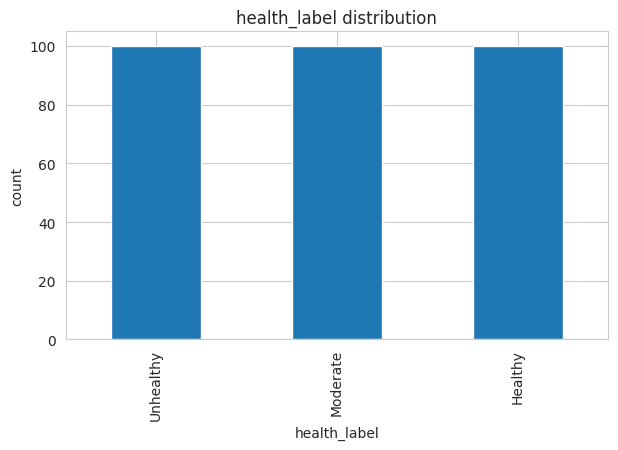

,mean,std,min,max
protein_g,8.121,11.512,0.0,147.060
fat_g,12.725,15.973,0.0,93.330
carbs_g,34.711,29.236,0.0,170.000
energy_kcal,278.596,189.562,0.0,941.000
sugars_g,14.092,19.462,0.0,140.000
fiber_g,3.304,6.239,0.0,66.700
sodium_mg,398.287,649.792,0.0,8143.000
potassium_mg,258.638,414.663,0.0,3900.000
cholesterol_mg,17.550,43.115,0.0,375.000
protein_ratio,0.034,0.038,0.0,0.229


In [3]:
# Missing values check
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts[na_counts > 0].to_frame('num_missing'))
assert na_counts.sum() == 0, 'Dataset contains NaNs; expected preprocessing to fill numeric NaNs with 0.'

# Label distribution
print(df['health_label'].value_counts())
ax = df['health_label'].value_counts().plot(kind='bar', title='health_label distribution')
ax.set_xlabel('health_label'); ax.set_ylabel('count')
plt.show()

# Quick numeric summary
numeric_cols = [c for c in required_cols if c not in ('description', 'health_label')]
display(df[numeric_cols].describe().T[['mean','std','min','max']].round(3))

# Validate processed_level range
assert set(df['processed_level'].unique()).issubset({0,1,2}), 'processed_level expected in {0,1,2}'

### 1.2 Quick EDA (feature distributions + correlations)

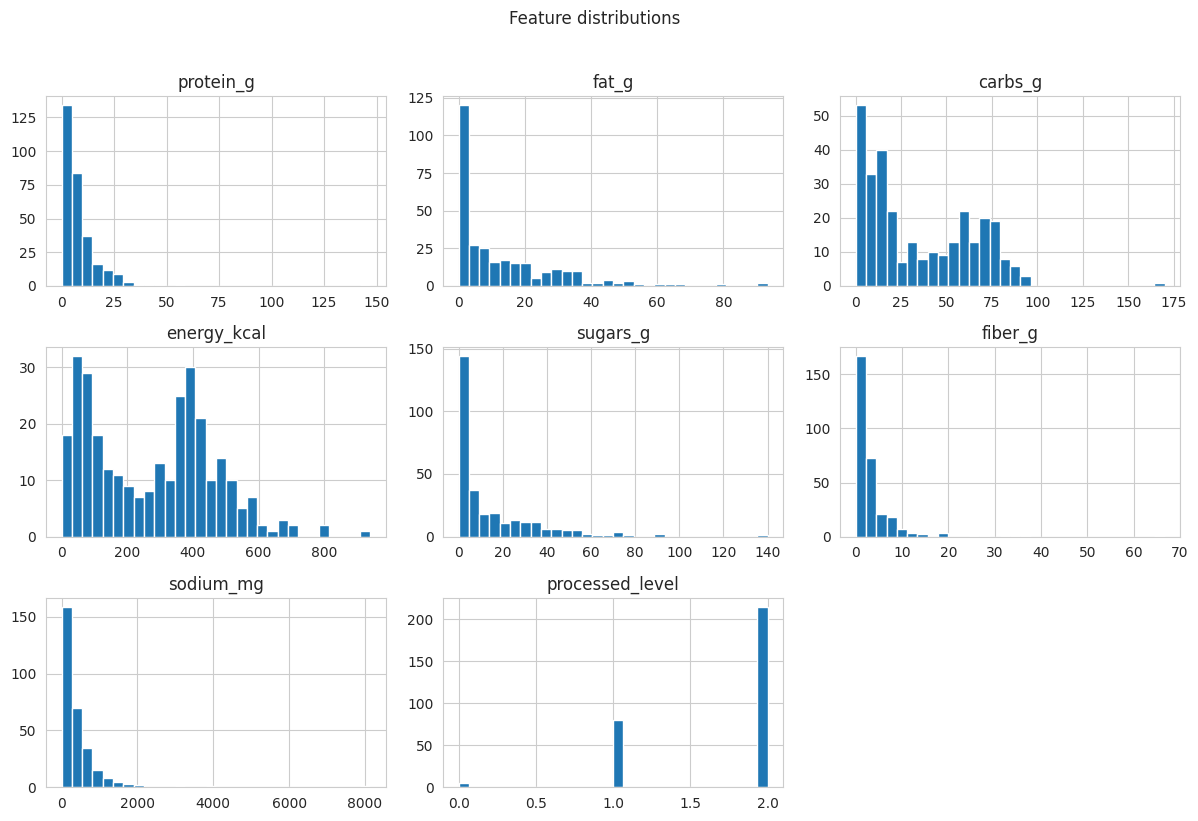

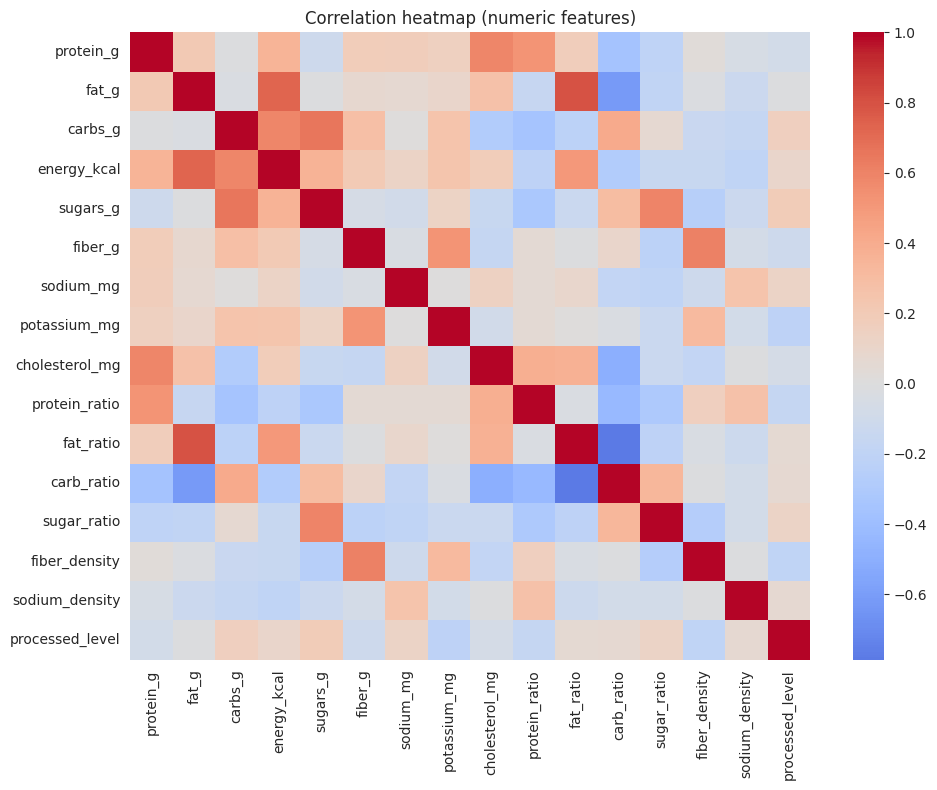

In [4]:
# Histograms for a few key features
plot_cols = ['protein_g','fat_g','carbs_g','energy_kcal','sugars_g','fiber_g','sodium_mg','processed_level']
plot_cols = [c for c in plot_cols if c in df.columns]
df[plot_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Feature distributions', y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric only)
numeric_cols = [c for c in required_cols if c not in ('description', 'health_label')]
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.show()

## 2) Training Setup — Features, Labels, and Split Strategy

We train with **Stratified K-Fold** to preserve the 3-class distribution in each fold. Standardization is fit on the training fold only (to avoid leakage) and applied to the validation fold.

In [5]:
# Features (numeric only) and target
feature_cols = [c for c in required_cols if c not in ('description', 'health_label')]
X = df[feature_cols].astype(np.float32).values

le = LabelEncoder()
y = le.fit_transform(df['health_label'].astype(str).values)
class_names = list(le.classes_)
num_classes = len(class_names)

print('X shape:', X.shape)
print('Classes:', class_names)
print('y distribution:', dict(zip(class_names, np.bincount(y))))

X shape: (300, 16)
Classes: ['Healthy', 'Moderate', 'Unhealthy']
y distribution: {'Healthy': np.int64(100), 'Moderate': np.int64(100), 'Unhealthy': np.int64(100)}


## 3) Model — PyTorch MLP + Training Loop

We use a small fully-connected network (MLP) with ReLU + Dropout. Training uses early stopping on validation loss.

In [6]:
def compute_metrics_multiclass(y_true, y_pred, y_proba, n_classes: int):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    auc = np.nan
    if y_proba is not None:
        try:
            auc = roc_auc_score(
                y_true, y_proba, multi_class='ovr', average='macro', labels=list(range(n_classes))
            )
        except ValueError:
            # Happens if a fold has a missing class in y_true
            auc = np.nan
    return {'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec, 'f1_macro': f1, 'auroc_ovr_macro': auc}


class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden_dims=(64, 32), dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def _prepare_fold_arrays(X_train, X_val, pca_components=None):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    if pca_components is not None:
        pca = PCA(n_components=pca_components, random_state=SEED)
        X_train_s = pca.fit_transform(X_train_s)
        X_val_s = pca.transform(X_val_s)
    return X_train_s.astype(np.float32), X_val_s.astype(np.float32)


def train_one_fold(
    X_train, y_train, X_val, y_val,
    *,
    n_classes: int,
    hidden_dims=(64, 32),
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=32,
    max_epochs=80,
    patience=10,
    class_weights=None,
    verbose=False,
):
    input_dim = X_train.shape[1]
    model = MLP(input_dim=input_dim, num_classes=n_classes, hidden_dims=hidden_dims, dropout=dropout).to(device)
    if class_weights is not None:
        weight_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=weight_t)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    Xtr_t = torch.tensor(X_train, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.long)
    Xva_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    yva_t = torch.tensor(y_val, dtype=torch.long, device=device)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)

    best_state = None
    best_val_loss = float('inf')
    bad = 0
    best_epoch = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(Xva_t)
            val_loss = criterion(val_logits, yva_t).item()

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f'Epoch {epoch:>3} | val_loss={val_loss:.4f}')

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(Xva_t)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        preds = probs.argmax(axis=1)

    return probs, preds, {'best_epoch': best_epoch, 'best_val_loss': best_val_loss}


def cv_evaluate_mlp(
    X, y,
    *,
    n_classes: int,
    class_names,
    n_splits=5,
    pca_components=None,
    use_class_weights=False,
    seed=SEED,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    all_true = []
    all_pred = []
    all_proba = []
    fold_metrics = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        X_tr_s, X_va_s = _prepare_fold_arrays(X_tr, X_va, pca_components=pca_components)

        cw = None
        if use_class_weights:
            cw = compute_class_weight('balanced', classes=np.arange(n_classes), y=y_tr)

        proba, pred, _info = train_one_fold(
            X_tr_s, y_tr, X_va_s, y_va, n_classes=n_classes, class_weights=cw
        )
        m = compute_metrics_multiclass(y_va, pred, proba, n_classes)
        fold_metrics.append(m)
        all_true.append(y_va)
        all_pred.append(pred)
        all_proba.append(proba)
        msg = ', '.join([f"{k}={v:.3f}" for k, v in m.items() if not np.isnan(v)])
        print(f'Fold {fold}: {msg}')

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.concatenate(all_proba)
    summary = compute_metrics_multiclass(y_true, y_pred, y_proba, n_classes)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    return {'fold_metrics': fold_metrics, 'summary': summary, 'cm': cm, 'report': report, 'y_true': y_true, 'y_pred': y_pred, 'y_proba': y_proba}

## 4) Training + Evaluation — Stratified Cross-Validation

This is the main baseline evaluation for the MLP.

Fold 1: accuracy=0.933, precision_macro=0.933, recall_macro=0.933, f1_macro=0.933, auroc_ovr_macro=0.974
Fold 2: accuracy=0.800, precision_macro=0.839, recall_macro=0.800, f1_macro=0.803, auroc_ovr_macro=0.957
Fold 3: accuracy=0.867, precision_macro=0.867, recall_macro=0.867, f1_macro=0.864, auroc_ovr_macro=0.942
Fold 4: accuracy=0.900, precision_macro=0.899, recall_macro=0.900, f1_macro=0.899, auroc_ovr_macro=0.974
Fold 5: accuracy=0.833, precision_macro=0.838, recall_macro=0.833, f1_macro=0.833, auroc_ovr_macro=0.960

Baseline summary:


,accuracy,precision_macro,recall_macro,f1_macro,auroc_ovr_macro
0,0.8667,0.8686,0.8667,0.8674,0.9569


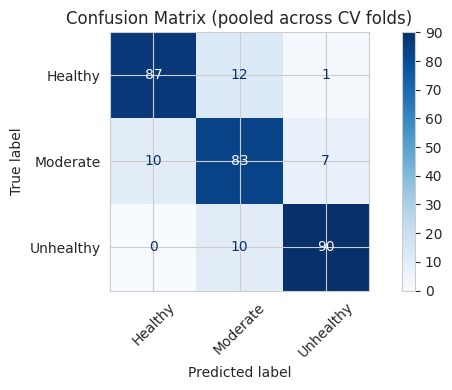

Classification report (pooled):
              precision    recall  f1-score   support

     Healthy       0.90      0.87      0.88       100
    Moderate       0.79      0.83      0.81       100
   Unhealthy       0.92      0.90      0.91       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300



In [7]:
baseline = cv_evaluate_mlp(
    X, y, n_classes=num_classes, class_names=class_names, n_splits=5, pca_components=None, use_class_weights=False
)

print('\nBaseline summary:')
display(pd.DataFrame([baseline['summary']]).round(4))

ConfusionMatrixDisplay(baseline['cm'], display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (pooled across CV folds)')
plt.tight_layout()
plt.show()

print('Classification report (pooled):')
print(baseline['report'])

## 5) Results Analysis

Use the outputs above to answer:
- Which classes are most frequently confused (from the confusion matrix)?
- Are there signs of class imbalance affecting macro-F1?
- Which features look highly correlated (from the heatmap), and how might that affect learning?

In [8]:
fold_df = pd.DataFrame(baseline['fold_metrics'])
display(fold_df.round(4))

print('Mean ± std across folds:')
mean_std = pd.DataFrame({'mean': fold_df.mean(), 'std': fold_df.std()})
display(mean_std.round(4))

,accuracy,precision_macro,recall_macro,f1_macro,auroc_ovr_macro
0,0.9333,0.9332,0.9333,0.9329,0.9742
1,0.8000,0.8386,0.8000,0.8031,0.9571
2,0.8667,0.8673,0.8667,0.8637,0.9421
3,0.9000,0.8995,0.9000,0.8986,0.9738
4,0.8333,0.8381,0.8333,0.8332,0.9596


Mean ± std across folds:


,mean,std
accuracy,0.8667,0.0527
precision_macro,0.8754,0.0410
recall_macro,0.8667,0.0527
f1_macro,0.8663,0.0514
auroc_ovr_macro,0.9613,0.0133


## 6) Experiments

A–D below mirror common evaluation questions: effect of data size, imbalance handling, augmentation, and dimensionality reduction.

Fold 1: accuracy=0.583, precision_macro=0.556, recall_macro=0.583, f1_macro=0.544, auroc_ovr_macro=0.854
Fold 2: accuracy=0.667, precision_macro=0.700, recall_macro=0.667, f1_macro=0.675, auroc_ovr_macro=0.927
Fold 3: accuracy=0.667, precision_macro=0.639, recall_macro=0.667, f1_macro=0.628, auroc_ovr_macro=0.885
Fold 4: accuracy=0.250, precision_macro=0.194, recall_macro=0.250, f1_macro=0.206, auroc_ovr_macro=0.583
Fold 5: accuracy=1.000, precision_macro=1.000, recall_macro=1.000, f1_macro=1.000, auroc_ovr_macro=1.000
Fold 1: accuracy=0.625, precision_macro=0.632, recall_macro=0.625, f1_macro=0.614, auroc_ovr_macro=0.807
Fold 2: accuracy=0.500, precision_macro=0.517, recall_macro=0.500, f1_macro=0.507, auroc_ovr_macro=0.807
Fold 3: accuracy=0.708, precision_macro=0.722, recall_macro=0.708, f1_macro=0.709, auroc_ovr_macro=0.854
Fold 4: accuracy=0.708, precision_macro=0.761, recall_macro=0.708, f1_macro=0.699, auroc_ovr_macro=0.911
Fold 5: accuracy=0.708, precision_macro=0.753, recall_m

,train_fraction,acc_mean,acc_std,f1_mean,f1_std
0,0.2,0.633333,0.267447,0.610635,0.284526
1,0.4,0.650000,0.091287,0.649477,0.089845
2,0.6,0.727778,0.110065,0.719656,0.120597
3,0.8,0.812500,0.141299,0.809325,0.141949
4,1.0,0.880000,0.047726,0.880333,0.047157


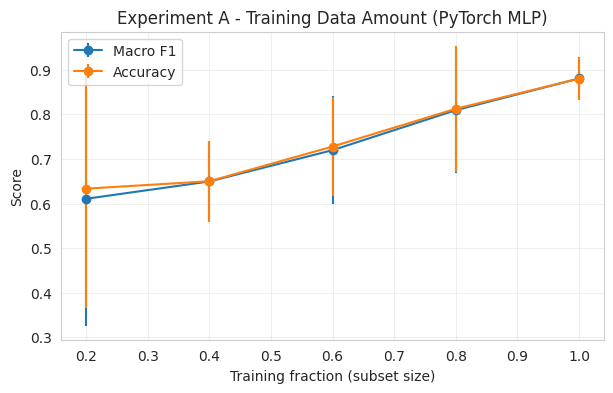

Imbalanced counts: Counter({np.int64(0): 100, np.int64(1): 100, np.int64(2): 30})
Fold 1: accuracy=0.717, precision_macro=0.653, recall_macro=0.589, f1_macro=0.592, auroc_ovr_macro=0.790
Fold 2: accuracy=0.870, precision_macro=0.908, recall_macro=0.783, f1_macro=0.817, auroc_ovr_macro=0.931
Fold 3: accuracy=0.848, precision_macro=0.901, recall_macro=0.767, f1_macro=0.802, auroc_ovr_macro=0.958
Fold 4: accuracy=0.870, precision_macro=0.904, recall_macro=0.861, f1_macro=0.879, auroc_ovr_macro=0.988
Fold 5: accuracy=0.826, precision_macro=0.828, recall_macro=0.828, f1_macro=0.827, auroc_ovr_macro=0.954
Fold 1: accuracy=0.848, precision_macro=0.786, recall_macro=0.767, f1_macro=0.775, auroc_ovr_macro=0.893
Fold 2: accuracy=0.804, precision_macro=0.740, recall_macro=0.772, f1_macro=0.743, auroc_ovr_macro=0.904
Fold 3: accuracy=0.870, precision_macro=0.837, recall_macro=0.861, f1_macro=0.847, auroc_ovr_macro=0.950
Fold 4: accuracy=0.870, precision_macro=0.848, recall_macro=0.900, f1_macro=0.

,method,acc,f1
0,baseline,0.826087,0.792866
1,class_weight,0.830435,0.797882
2,SMOTE,0.821739,0.800426


Fold 1: accuracy=0.933, precision_macro=0.933, recall_macro=0.933, f1_macro=0.933, auroc_ovr_macro=0.977
Fold 2: accuracy=0.833, precision_macro=0.858, recall_macro=0.833, f1_macro=0.837, auroc_ovr_macro=0.948
Fold 3: accuracy=0.833, precision_macro=0.837, recall_macro=0.833, f1_macro=0.830, auroc_ovr_macro=0.942
Fold 4: accuracy=0.883, precision_macro=0.883, recall_macro=0.883, f1_macro=0.883, auroc_ovr_macro=0.970
Fold 5: accuracy=0.867, precision_macro=0.873, recall_macro=0.867, f1_macro=0.867, auroc_ovr_macro=0.966
Experiment C: augmentation


,setting,acc,f1
0,no_aug,0.87,0.870378
1,gaussian_aug,0.88,0.880148


Fold 1: accuracy=0.733, precision_macro=0.731, recall_macro=0.733, f1_macro=0.732, auroc_ovr_macro=0.899
Fold 2: accuracy=0.633, precision_macro=0.637, recall_macro=0.633, f1_macro=0.630, auroc_ovr_macro=0.810
Fold 3: accuracy=0.667, precision_macro=0.667, recall_macro=0.667, f1_macro=0.662, auroc_ovr_macro=0.839
Fold 4: accuracy=0.767, precision_macro=0.794, recall_macro=0.767, f1_macro=0.760, auroc_ovr_macro=0.922
Fold 5: accuracy=0.617, precision_macro=0.611, recall_macro=0.617, f1_macro=0.606, auroc_ovr_macro=0.810
Fold 1: accuracy=0.783, precision_macro=0.787, recall_macro=0.783, f1_macro=0.782, auroc_ovr_macro=0.947
Fold 2: accuracy=0.550, precision_macro=0.545, recall_macro=0.550, f1_macro=0.547, auroc_ovr_macro=0.759
Fold 3: accuracy=0.717, precision_macro=0.712, recall_macro=0.717, f1_macro=0.704, auroc_ovr_macro=0.846
Fold 4: accuracy=0.800, precision_macro=0.801, recall_macro=0.800, f1_macro=0.796, auroc_ovr_macro=0.952
Fold 5: accuracy=0.633, precision_macro=0.645, recall_m

,pca_components,acc_mean,f1_mean
0,3,0.683333,0.678880
1,5,0.696667,0.692916
2,8,0.836667,0.836566
3,12,0.853333,0.853243


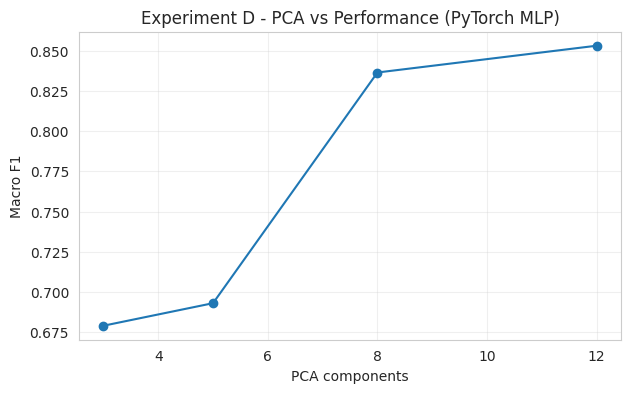

In [9]:
# 6.1 Experiment helpers (A-D)
from collections import Counter
from imblearn.over_sampling import SMOTE


def stratified_subsample(X, y, frac, seed=SEED):
    frac = float(frac)
    if frac <= 0.0 or frac > 1.0:
        raise ValueError('frac must be in the range (0, 1].')
    if frac == 1.0:
        return X.copy(), y.copy()

    sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=seed)
    (idx, _), = sss.split(X, y)
    return X[idx], y[idx]


def simulate_imbalance(X, y, keep_fraction_for_last_class=0.30, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    target = classes[-1]  # downsample one class
    idx_target = np.where(y == target)[0]
    idx_other = np.where(y != target)[0]
    keep_n = max(10, int(len(idx_target) * keep_fraction_for_last_class))
    keep_idx = rng.choice(idx_target, size=keep_n, replace=False)
    idx = np.concatenate([idx_other, keep_idx])
    rng.shuffle(idx)
    return X[idx], y[idx]


def augment_gaussian(Xtr, ytr, copies=2, noise_std=0.015, seed=SEED):
    rng = np.random.default_rng(seed)
    feat_std = Xtr.std(axis=0, keepdims=True)
    feat_std = np.where(feat_std == 0, 1.0, feat_std)
    xs = [Xtr]
    ys = [ytr]
    for _ in range(copies):
        noise = rng.normal(0.0, noise_std, size=Xtr.shape) * feat_std
        xs.append(Xtr + noise)
        ys.append(ytr)
    return np.vstack(xs), np.concatenate(ys)


def cv_evaluate_mlp_with_augmentation(
    X, y, *, n_classes, class_names, n_splits=5, copies=2, noise_std=0.015, seed=SEED
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_metrics, all_true, all_pred, all_proba = [], [], [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        X_tr_s, X_va_s = _prepare_fold_arrays(X_tr, X_va, pca_components=None)
        X_aug, y_aug = augment_gaussian(X_tr_s, y_tr, copies=copies, noise_std=noise_std, seed=seed + fold)

        proba, pred, _info = train_one_fold(X_aug, y_aug, X_va_s, y_va, n_classes=n_classes)
        m = compute_metrics_multiclass(y_va, pred, proba, n_classes)
        fold_metrics.append(m)
        all_true.append(y_va)
        all_pred.append(pred)
        all_proba.append(proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.concatenate(all_proba)
    summary = compute_metrics_multiclass(y_true, y_pred, y_proba, n_classes)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    return {'fold_metrics': fold_metrics, 'summary': summary, 'cm': cm, 'report': report}


def cv_evaluate_mlp_smote(X, y, *, n_classes, class_names, n_splits=5, seed=SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_metrics, all_true, all_pred, all_proba = [], [], [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        # Scale first, then apply SMOTE on training data only.
        X_tr_s, X_va_s = _prepare_fold_arrays(X_tr, X_va, pca_components=None)
        sm = SMOTE(random_state=seed)
        X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_s, y_tr)

        proba, pred, _info = train_one_fold(X_tr_bal, y_tr_bal, X_va_s, y_va, n_classes=n_classes)
        m = compute_metrics_multiclass(y_va, pred, proba, n_classes)
        fold_metrics.append(m)
        all_true.append(y_va)
        all_pred.append(pred)
        all_proba.append(proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.concatenate(all_proba)
    summary = compute_metrics_multiclass(y_true, y_pred, y_proba, n_classes)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    return {'fold_metrics': fold_metrics, 'summary': summary, 'cm': cm, 'report': report}


# A) Effect of training-data amount
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for frac in fractions:
    Xs, ys = stratified_subsample(X, y, frac, seed=SEED)
    out = cv_evaluate_mlp(Xs, ys, n_classes=num_classes, class_names=class_names, n_splits=5)
    fold_df = pd.DataFrame(out['fold_metrics'])
    rows.append({
        'train_fraction': frac,
        'acc_mean': float(fold_df['accuracy'].mean()),
        'acc_std': float(fold_df['accuracy'].std()),
        'f1_mean': float(fold_df['f1_macro'].mean()),
        'f1_std': float(fold_df['f1_macro'].std()),
    })
expA = pd.DataFrame(rows)
print('Experiment A: training-data amount')
display(expA)

plt.errorbar(expA['train_fraction'], expA['f1_mean'], yerr=expA['f1_std'], marker='o', label='Macro F1')
plt.errorbar(expA['train_fraction'], expA['acc_mean'], yerr=expA['acc_std'], marker='o', label='Accuracy')
plt.xlabel('Training fraction (subset size)')
plt.ylabel('Score')
plt.title('Experiment A - Training Data Amount (PyTorch MLP)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# B) Composition/balance: baseline vs class-weight vs SMOTE
X_imb, y_imb = simulate_imbalance(X, y, keep_fraction_for_last_class=0.30, seed=SEED)
print('Imbalanced counts:', Counter(y_imb))

out_base = cv_evaluate_mlp(X_imb, y_imb, n_classes=num_classes, class_names=class_names, n_splits=5, use_class_weights=False)
out_w = cv_evaluate_mlp(X_imb, y_imb, n_classes=num_classes, class_names=class_names, n_splits=5, use_class_weights=True)
out_smote = cv_evaluate_mlp_smote(X_imb, y_imb, n_classes=num_classes, class_names=class_names, n_splits=5)

expB = pd.DataFrame([
    {'method': 'baseline', 'acc': out_base['summary']['accuracy'], 'f1': out_base['summary']['f1_macro']},
    {'method': 'class_weight', 'acc': out_w['summary']['accuracy'], 'f1': out_w['summary']['f1_macro']},
    {'method': 'SMOTE', 'acc': out_smote['summary']['accuracy'], 'f1': out_smote['summary']['f1_macro']},
])
print('Experiment B: class-imbalance handling')
display(expB)


# C) Data augmentation: no augmentation vs Gaussian augmentation
out_no_aug = cv_evaluate_mlp(X, y, n_classes=num_classes, class_names=class_names, n_splits=5)
out_aug = cv_evaluate_mlp_with_augmentation(
    X, y, n_classes=num_classes, class_names=class_names, n_splits=5, copies=2, noise_std=0.015
)
expC = pd.DataFrame([
    {'setting': 'no_aug', 'acc': out_no_aug['summary']['accuracy'], 'f1': out_no_aug['summary']['f1_macro']},
    {'setting': 'gaussian_aug', 'acc': out_aug['summary']['accuracy'], 'f1': out_aug['summary']['f1_macro']},
])
print('Experiment C: augmentation')
display(expC)


# D) Dimensionality reduction: PCA sweep
pca_components_list = [3, 5, 8, 12]
rows = []
for k in pca_components_list:
    out_pca = cv_evaluate_mlp(X, y, n_classes=num_classes, class_names=class_names, n_splits=5, pca_components=k)
    rows.append({
        'pca_components': k,
        'acc_mean': out_pca['summary']['accuracy'],
        'f1_mean': out_pca['summary']['f1_macro'],
    })
expD = pd.DataFrame(rows)
print('Experiment D: PCA vs no PCA')
display(expD)

plt.plot(expD['pca_components'], expD['f1_mean'], marker='o')
plt.xlabel('PCA components')
plt.ylabel('Macro F1')
plt.title('Experiment D - PCA vs Performance (PyTorch MLP)')
plt.grid(True, alpha=0.3)
plt.show()

## 7) Discussion

Use your observed outputs (`expA`, `expB`, `expC`, `expD`, confusion matrix, and fold-level stats) to write your conclusions:

1) Are the results and behaviors expected?
- Compare trends in `expA` (data amount) with your intuition.
- Note whether variance shrinks as training fraction grows.

2) What factors affect results?
- Dataset size and class balance.
- Correlated features and potential redundancy.
- Model capacity / regularization (hidden dims, dropout, early stopping).

3) What would you do with more time?
- Hyperparameter search (hidden dims, dropout, LR, epochs, patience).
- Stronger augmentation variants and repeated runs with different seeds.
- Compare against additional baselines (logistic regression, random forest, XGBoost).

4) What did you learn and what remains open?
- Summarize your main findings in 3-5 bullets.
- List unresolved questions (for example, calibration quality, label noise, or feature engineering limits).